**Capítulo 2 – Projeto de Machine Learning de ponta a ponta**

*Bem-vindo à Machine Learning Housing Corp.! Sua tarefa é prever os valores medianos das casas em distritos da Califórnia, dado um número de características desses distritos.*

*Este notebook contém todo o código de exemplo e soluções para os exercícios do capítulo 2.*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/02_end_to_end_machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml2/blob/master/02_end_to_end_machine_learning_project.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

Primeiro, vamos importar alguns módulos comuns, garantir que as figuras do MatplotLib sejam exibidas inline e preparar uma função para salvar as figuras. Também verificamos se o Python 3.5 ou posterior está instalado (embora o Python 2.x possa funcionar, ele está obsoleto, então recomendamos fortemente que você use o Python 3), assim como o Scikit-Learn ≥0.20.

In [5]:
# Python ≥3.5 é necessário
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 é necessário
import sklearn
assert sklearn.__version__ >= "0.20"

# Imports comuns
import numpy as np
import os

# Para plotar figuras bonitas
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Onde salvar as figuras
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Salvando figura", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Obtenha os dados

## Baixar os dados

In [6]:
import os
import tarfile
import urllib.request

# URL raiz do repositório GitHub com os dados
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
# Caminho local onde os dados serão salvos
HOUSING_PATH = os.path.join("datasets", "housing")
# URL completa do arquivo de dados compactado
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    """Baixa e extrai o dataset de habitação da Califórnia"""
    # Cria o diretório se não existir
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    # Define o caminho completo do arquivo .tgz
    tgz_path = os.path.join(housing_path, "housing.tgz")
    # Faz o download do arquivo
    urllib.request.urlretrieve(housing_url, tgz_path)
    # Abre o arquivo compactado
    housing_tgz = tarfile.open(tgz_path)
    # Extrai todos os arquivos para o diretório
    housing_tgz.extractall(path=housing_path)
    # Fecha o arquivo
    housing_tgz.close()

In [7]:
fetch_housing_data()

C:\Users\cloud\AppData\Local\Temp\ipykernel_18420\3990830318.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [8]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    """Carrega o dataset de habitação do arquivo CSV"""
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

## Dê uma olhada rápida na estrutura de dados

In [9]:
# Carrega o dataset de habitação
housing = load_housing_data()
# Exibe as primeiras 5 linhas do DataFrame
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
# Exibe informações sobre o DataFrame (colunas, tipos de dados, valores não-nulos, uso de memória)
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [11]:
# Conta a frequência de cada categoria na coluna "ocean_proximity"
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [12]:
# Exibe estatísticas descritivas das colunas numéricas (contagem, média, desvio padrão, mín, quartis, máx)
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Salvando figura attribute_histogram_plots


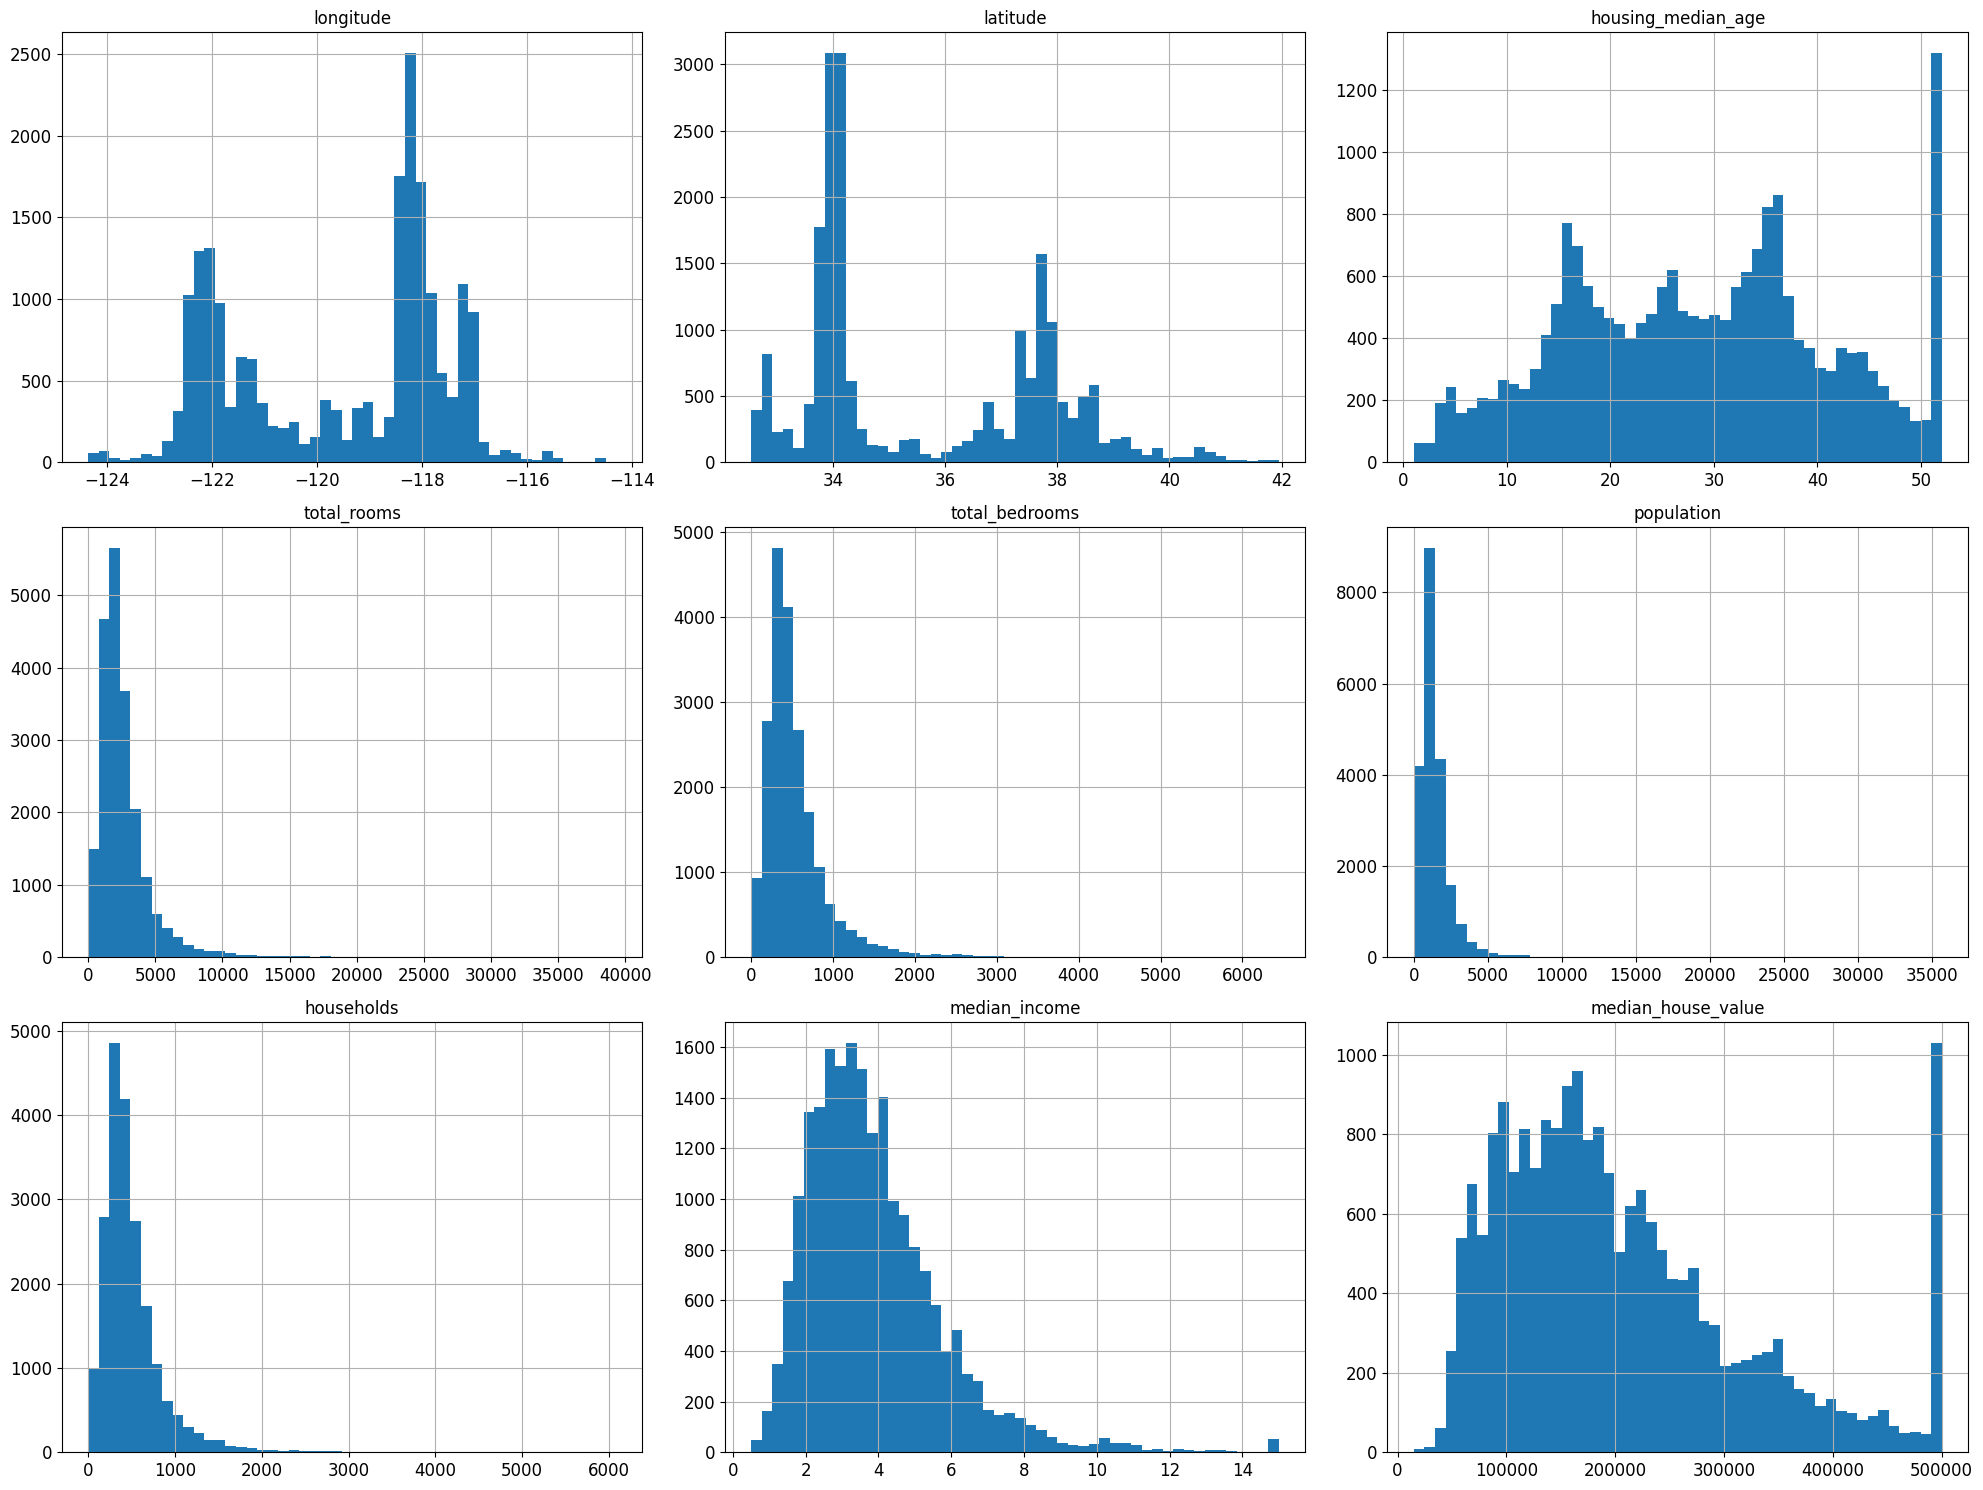

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
# Cria histogramas de todas as colunas numéricas com 50 bins
housing.hist(bins=50, figsize=(20,15))
# Salva a figura gerada
save_fig("attribute_histogram_plots")
# Exibe os gráficos
plt.show()

## Criar um conjunto de testes

In [14]:
# Para tornar a saída deste notebook idêntica a cada execução
np.random.seed(42)

In [15]:
import numpy as np

# Apenas para ilustração. O Sklearn possui train_test_split()
def split_train_test(data, test_ratio):
    """Divide os dados em conjuntos de treino e teste"""
    # Embaralha os índices aleatoriamente
    shuffled_indices = np.random.permutation(len(data))
    # Calcula o tamanho do conjunto de teste
    test_set_size = int(len(data) * test_ratio)
    # Separa os índices para teste
    test_indices = shuffled_indices[:test_set_size]
    # Separa os índices para treino
    train_indices = shuffled_indices[test_set_size:]
    # Retorna os DataFrames de treino e teste
    return data.iloc[train_indices], data.iloc[test_indices]

In [16]:
# Divide o dataset em treino (80%) e teste (20%)
train_set, test_set = split_train_test(housing, 0.2)
# Retorna o número de amostras no conjunto de treino
len(train_set)

16512

In [17]:
# Retorna o número de amostras no conjunto de teste
len(test_set)

4128

In [18]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    """Verifica se um identificador deve ir para o conjunto de teste usando hash CRC32"""
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    """Divide dados em treino/teste baseado em um identificador único"""
    # Obtém a coluna de IDs
    ids = data[id_column]
    # Determina quais IDs vão para o conjunto de teste
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    # Retorna treino (não está em teste) e teste
    return data.loc[~in_test_set], data.loc[in_test_set]

A implementação de `test_set_check()` acima funciona bem tanto em Python 2 quanto em Python 3. Em versões anteriores, foi proposta a seguinte implementação, que suportava qualquer função hash, mas era muito mais lenta e não suportava Python 2:

In [19]:
import hashlib

def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    """
    Verifica se um identificador pertence ao conjunto de teste usando hash MD5
    Alternativa mais robusta usando hashlib em vez de CRC32
    """
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

Se você deseja uma implementação que suporte qualquer função hash e seja compatível com Python 2 e Python 3, aqui está uma:

In [20]:
def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    """
    Verifica se um identificador pertence ao conjunto de teste usando hash MD5
    Usa bytearray para garantir compatibilidade entre versões do Python
    """
    # Converte o hash para bytearray, pega o último byte e compara com o limiar
    return bytearray(hash(np.int64(identifier)).digest())[-1] < 256 * test_ratio

In [21]:
# Adiciona uma coluna 'index' ao dataset
housing_with_id = housing.reset_index()
# Divide em treino/teste usando o índice como identificador
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [22]:
# Cria um ID único combinando longitude e latitude
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
# Divide em treino/teste usando o ID geográfico como identificador
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [23]:
# Exibe as primeiras 5 linhas do conjunto de teste
test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
8,8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,-122222.16
10,10,-122.26,37.85,52.0,2202.0,434.0,910.0,402.0,3.2031,281500.0,NEAR BAY,-122222.15
11,11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY,-122222.15
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY,-122222.15
13,13,-122.26,37.84,52.0,696.0,191.0,345.0,174.0,2.6736,191300.0,NEAR BAY,-122222.16


In [24]:
from sklearn.model_selection import train_test_split

# Divide o dataset em treino (80%) e teste (20%) usando a função do sklearn
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [25]:
# Exibe as primeiras 5 linhas do conjunto de teste
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


<Axes: >

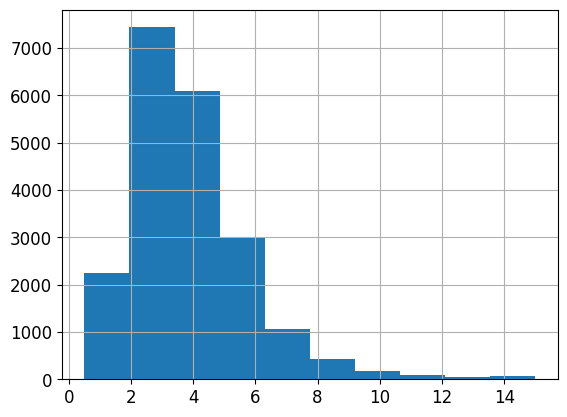

In [26]:
# Cria um histograma da renda mediana
housing["median_income"].hist()

In [27]:
# Cria categorias de renda dividindo a renda mediana em 5 faixas
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [28]:
# Conta a frequência de cada categoria de renda
housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

<Axes: >

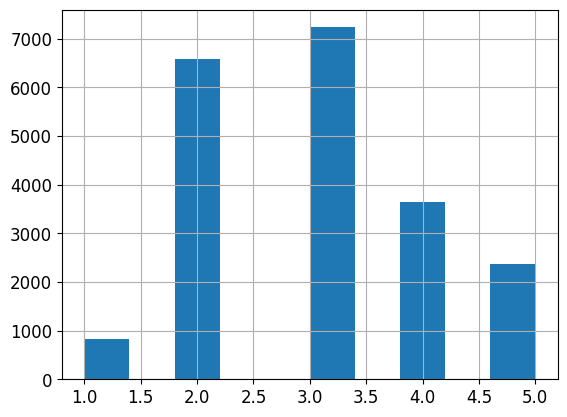

In [29]:
# Cria um histograma das categorias de renda
housing["income_cat"].hist()

In [30]:
from sklearn.model_selection import StratifiedShuffleSplit

# Cria um divisor estratificado que mantém a proporção das categorias de renda
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# Itera sobre a divisão (apenas 1 iteração neste caso)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    # Cria conjunto de treino estratificado
    strat_train_set = housing.loc[train_index]
    # Cria conjunto de teste estratificado
    strat_test_set = housing.loc[test_index]

In [31]:
# Calcula a proporção de cada categoria de renda no conjunto de teste estratificado
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [32]:
# Calcula a proporção de cada categoria de renda no dataset original completo
housing["income_cat"].value_counts() / len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [33]:
def income_cat_proportions(data):
    """Calcula a proporção de cada categoria de renda nos dados"""
    return data["income_cat"].value_counts() / len(data)

# Divisão aleatória simples (sem estratificação)
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Cria DataFrame comparando as proporções de cada método de divisão
compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),           # Dataset original
    "Stratified": income_cat_proportions(strat_test_set), # Divisão estratificada
    "Random": income_cat_proportions(test_set),           # Divisão aleatória
}).sort_index()
# Calcula o erro percentual da divisão aleatória
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
# Calcula o erro percentual da divisão estratificada
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [34]:
# Exibe a comparação das proporções e erros percentuais entre os métodos de divisão
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [35]:
# Remove a coluna temporária "income_cat" dos conjuntos estratificados
# axis=1: remove coluna, inplace=True: modifica o DataFrame original
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Descubra e visualize os dados para obter insights

In [ ]:
# Cria uma cópia do conjunto de treino para exploração e visualização
housing = strat_train_set.copy()

## Visualizando Dados Geográficos

Salvando figura bad_visualization_plot


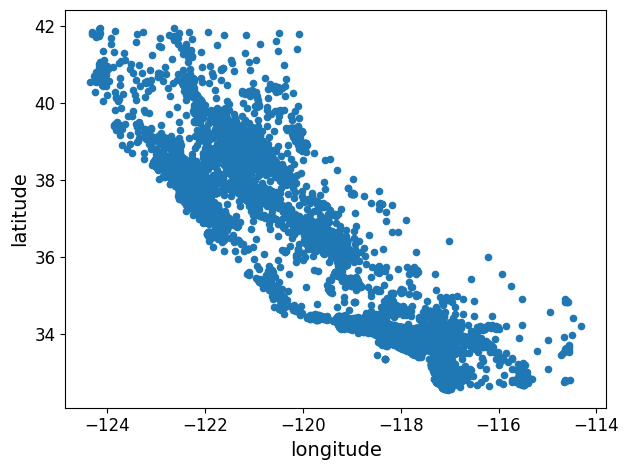

In [36]:
# Cria um gráfico de dispersão das localizações geográficas (visualização básica)
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig("bad_visualization_plot")

Salvando figura better_visualization_plot


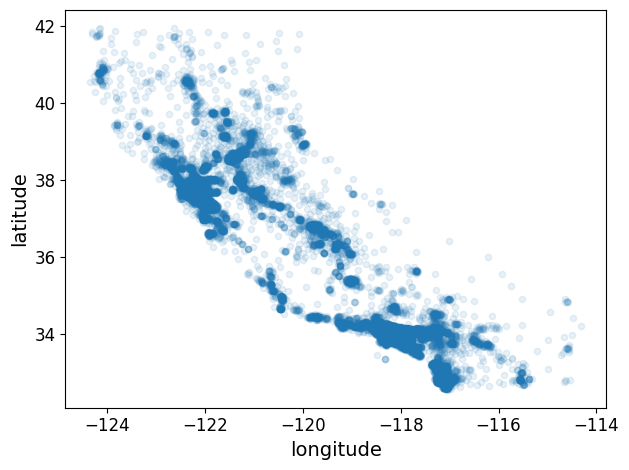

In [37]:
# Gráfico de dispersão com transparência (alpha=0.1) para melhor visualizar áreas densas
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
save_fig("better_visualization_plot")

O argumento `sharex=False` corrige um erro de exibição (os valores do eixo x e a legenda não eram exibidos). Esta é uma correção temporária (veja: https://github.com/pandas-dev/pandas/issues/10611). Agradecemos a Wilmer Arellano por ter apontado o problema.

Salvando figura housing_prices_scatterplot


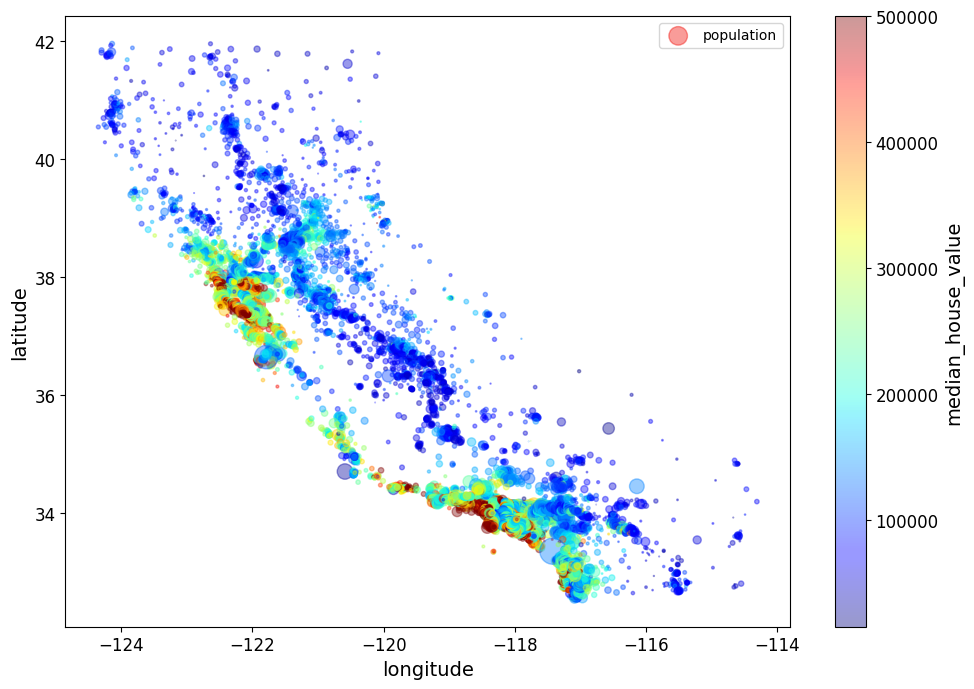

In [38]:
# Gráfico de dispersão avançado: mapa da Califórnia com preços das casas
# Tamanho dos pontos = população, cor = valor mediano das casas
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend()
save_fig("housing_prices_scatterplot")

In [39]:
# Baixa a imagem da Califórnia do repositório GitHub
images_path = os.path.join(PROJECT_ROOT_DIR, "images", "end_to_end_project")
os.makedirs(images_path, exist_ok=True)  # Cria o diretório se não existir
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Baixando", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))  # Faz o download

Baixando california.png


('.\\images\\end_to_end_project\\california.png',
 <http.client.HTTPMessage at 0x22be4865eb0>)

Salvando figura california_housing_prices_plot


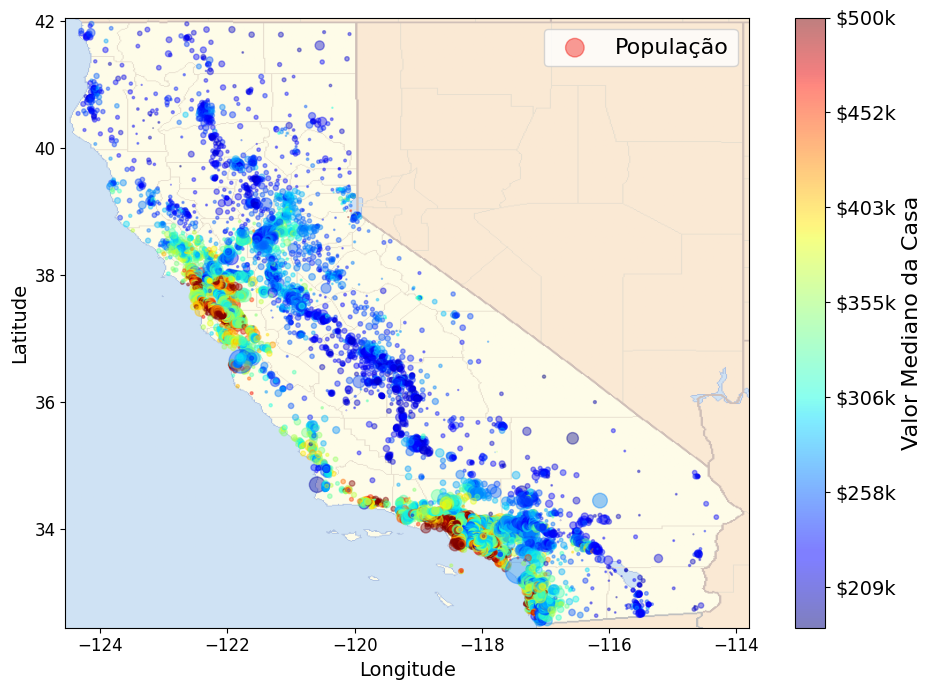

In [43]:
import matplotlib.image as mpimg
# Carrega a imagem da Califórnia
california_img=mpimg.imread(os.path.join(images_path, filename))
# Cria gráfico de dispersão com os dados de habitação
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=housing['population']/100, label="População",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
# Sobrepõe a imagem da Califórnia no gráfico
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

# Configura a barra de cores com os valores dos preços
prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Valor Mediano da Casa', fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()

## Buscando Correlações

In [46]:
# Calcula a matriz de correlação entre todas as variáveis numéricas
# numeric_only=True: ignora colunas não numéricas como 'ocean_proximity'
corr_matrix = housing.corr(numeric_only=True)

In [48]:
# Correlação de todas as features com o valor mediano das casas (ordem decrescente)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

Salvando figura scatter_matrix_plot


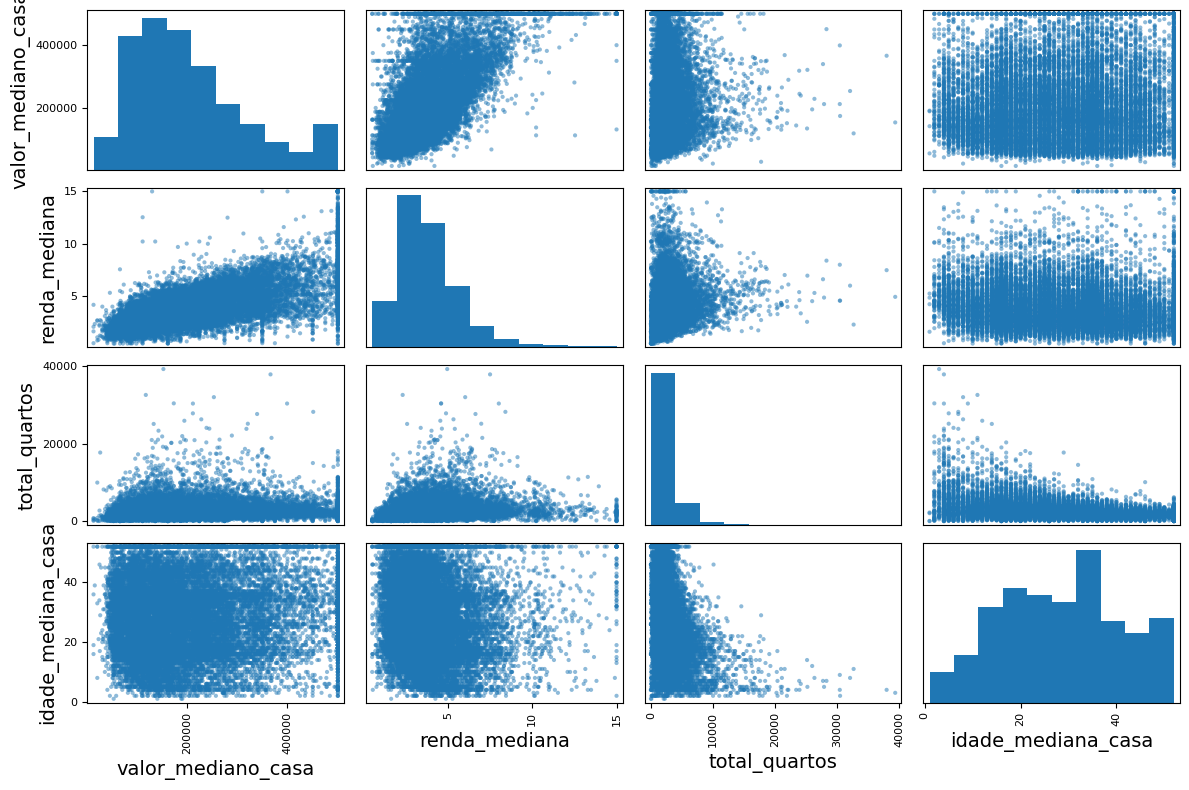

In [50]:
# from pandas.tools.plotting import scatter_matrix # Para versões antigas do Pandas
from pandas.plotting import scatter_matrix

# Define os atributos mais importantes para análise de correlação
attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]

# Cria um DataFrame com nomes traduzidos para as colunas
housing_traduzido = housing[attributes].copy()
housing_traduzido.columns = ["valor_mediano_casa", "renda_mediana", "total_quartos",
                              "idade_mediana_casa"]

# Cria matriz de gráficos de dispersão entre os atributos selecionados
scatter_matrix(housing_traduzido, figsize=(12, 8))
save_fig("scatter_matrix_plot")

Salvando figura income_vs_house_value_scatterplot


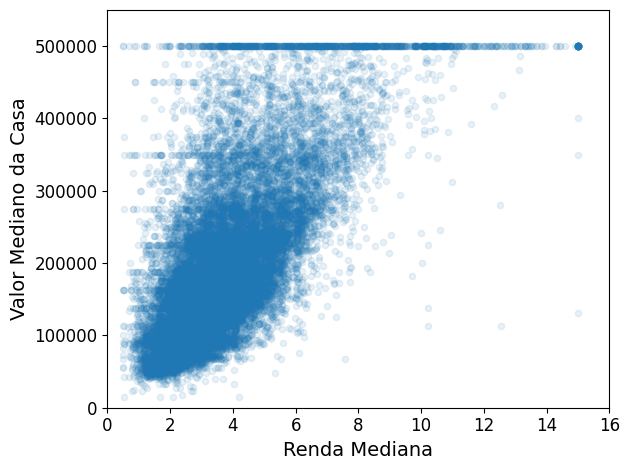

In [51]:
# Gráfico de dispersão: renda mediana vs valor mediano da casa
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)
plt.axis([0, 16, 0, 550000])
plt.xlabel("Renda Mediana")
plt.ylabel("Valor Mediano da Casa")
save_fig("income_vs_house_value_scatterplot")

## Experimentando com Combinações de Atributos

In [52]:
# Engenharia de features: cria novas variáveis combinando as existentes
# Quartos por domicílio: pode indicar tamanho médio das casas
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
# Quartos de dormir por quarto: proporção de quartos que são dormitórios
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
# População por domicílio: número médio de pessoas por casa
housing["population_per_household"]=housing["population"]/housing["households"]

In [53]:
# Recalcula a matriz de correlação incluindo as novas features criadas
corr_matrix = housing.corr(numeric_only=True)
# Mostra as correlações com o valor mediano das casas (ordem decrescente)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

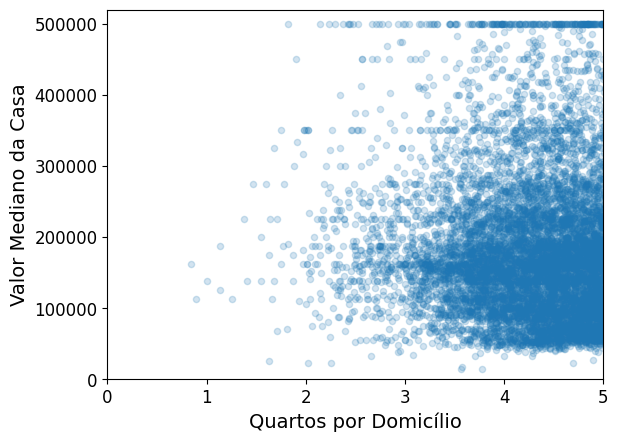

In [54]:
# Gráfico de dispersão: quartos por domicílio vs valor mediano da casa
housing.plot(kind="scatter", x="rooms_per_household", y="median_house_value",
             alpha=0.2)
plt.axis([0, 5, 0, 520000])
plt.xlabel("Quartos por Domicílio")
plt.ylabel("Valor Mediano da Casa")
plt.show()

In [56]:
# Exibe estatísticas descritivas atualizadas (incluindo as novas features criadas)
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,5.429000,0.213039,3.070655
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,2.474173,0.057983,10.386050
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,4.440716,0.175427,2.429741
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129,0.203162,2.818116
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,6.052381,0.239821,3.282261
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,1243.333333


# Preparar os dados para algoritmos de aprendizado de máquina

In [57]:
# Separa as features dos labels (variável alvo) no conjunto de treino
housing = strat_train_set.drop("median_house_value", axis=1)  # Remove labels do conjunto de treino
housing_labels = strat_train_set["median_house_value"].copy()  # Cria cópia dos labels

## Limpeza de Dados

No livro 3 opções são listadas:
```python
housing.dropna(subset=["total_bedrooms"])    # opção 1
housing.drop("total_bedrooms", axis=1)       # opção 2
median = housing["total_bedrooms"].median()  # opção 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

Para demonstrar cada uma delas, vamos criar uma cópia do dataset de habitação, mas mantendo apenas as linhas que contêm pelo menos um valor nulo. Então será mais fácil visualizar exatamente o que cada opção faz:

In [58]:
# Seleciona as primeiras linhas que contêm pelo menos um valor nulo
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN


In [59]:
# Opção 1: Remove as linhas que têm valores ausentes em "total_bedrooms"
sample_incomplete_rows.dropna(subset=["total_bedrooms"])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [60]:
# Opção 2: Remove a coluna "total_bedrooms" completamente
sample_incomplete_rows.drop("total_bedrooms", axis=1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,1145.0,480.0,6.3580,NEAR OCEAN


In [61]:
# Opção 3: Substitui valores ausentes pela mediana
median = housing["total_bedrooms"].median()  # Calcula a mediana
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True)  # Preenche NaN com a mediana

C:\Users\cloud\AppData\Local\Temp\ipykernel_18420\2828432031.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True)  # Preenche NaN com a mediana


In [62]:
# Exibe as linhas após aplicar a opção 3 (valores ausentes foram preenchidos)
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580,NEAR OCEAN


In [63]:
# Importa o SimpleImputer para tratamento de valores ausentes
from sklearn.impute import SimpleImputer
# Cria um imputer que preencherá valores ausentes com a mediana
imputer = SimpleImputer(strategy="median")

Remova o atributo de texto, pois a mediana só pode ser calculada com base em atributos numéricos:

In [64]:
# Remove a coluna de texto "ocean_proximity" (mediana só funciona com números)
housing_num = housing.drop("ocean_proximity", axis=1)
# alternativamente: housing_num = housing.select_dtypes(include=[np.number])  # Seleciona apenas colunas numéricas

In [65]:
# Ajusta o imputer aos dados (calcula a mediana de cada coluna numérica)
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [66]:
imputer.statistics_  # Valores das medianas aprendidas (uma para cada feature)

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

Verifique se isso é o mesmo que calcular manualmente a mediana de cada atributo:

In [68]:
# Calcula as medianas manualmente para verificação (deve ser igual ao imputer.statistics_)
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

Transforme o conjunto de treinamento:

In [69]:
X = imputer.transform(housing_num)  # Preenche os valores ausentes com as medianas

In [70]:
# Converte o array numpy de volta para DataFrame mantendo colunas e índices originais
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing.index)

In [71]:
# Exibe as linhas que antes tinham valores ausentes (agora preenchidos com medianas)
housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580


In [72]:
imputer.strategy  # Mostra a estratégia configurada ("median")

'median'

In [73]:
# Converte o array transformado de volta para DataFrame com os índices corretos
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [74]:
# Exibe as primeiras 5 linhas do DataFrame transformado (com valores imputados)
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


## Manipulação de atributos de texto e categóricos

Agora vamos pré-processar a variável de entrada categórica, `ocean_proximity`:

In [78]:
# Seleciona apenas a coluna categórica "ocean_proximity"
housing_cat = housing[["ocean_proximity"]]
# Exibe as primeiras 10 linhas
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [79]:
from sklearn.preprocessing import OrdinalEncoder

# Cria um codificador ordinal para converter categorias em números
ordinal_encoder = OrdinalEncoder()
# Ajusta e transforma a coluna categórica em valores numéricos
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
# Exibe os primeiros 10 valores codificados
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [80]:
# Exibe as categorias únicas encontradas pelo encoder
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [82]:
from sklearn.preprocessing import OneHotEncoder

# Inicializa o OneHotEncoder (converte categorias em colunas binárias separadas)
cat_encoder = OneHotEncoder()
# Transforma cada categoria em um vetor binário (matriz esparsa)
# Por exemplo: "NEAR BAY" pode se tornar [1, 0, 0, 0, 0]
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot  # Retorna uma matriz esparsa (sparse matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

Por padrão, a classe `OneHotEncoder` retorna um array esparso, mas podemos convertê-lo em um array denso, se necessário, chamando o método `toarray()`:

In [86]:
# Converte a matriz esparsa em um array numpy denso (para visualização)
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

Alternativamente, você pode definir `sparse=False` ao criar o `OneHotEncoder`:

In [87]:
# Cria um codificador one-hot que retorna array denso (não esparso)
# Nota: em versões recentes do sklearn, o parâmetro mudou de 'sparse' para 'sparse_output'
cat_encoder = OneHotEncoder(sparse_output=False)
# Transforma a coluna categórica em array one-hot denso
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [88]:
cat_encoder.categories_  # Lista das categorias (cada uma vira uma coluna no one-hot)

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Transformers personalizados

Vamos criar um transformador personalizado para adicionar atributos extras:

In [89]:
from sklearn.base import BaseEstimator, TransformerMixin

# Índices das colunas numéricas relevantes
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    """
    Transformador customizado que cria novas features através de combinações
    Herda de BaseEstimator e TransformerMixin para compatibilidade com pipelines do sklearn
    """
    def __init__(self, add_bedrooms_per_room=True): # sem *args ou **kwargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X, y=None):
        return self  # nada a aprender, apenas retorna self
    
    def transform(self, X):
        # Cria novas features combinando as existentes
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            # Concatena as novas colunas ao array original
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# Instancia o transformador sem a feature bedrooms_per_room
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
# Transforma os dados adicionando as novas features
housing_extra_attribs = attr_adder.transform(housing.values)

Observe que eu codifiquei os índices (3, 4, 5, 6) diretamente no livro para maior concisão e clareza, mas seria muito mais organizado obtê-los dinamicamente, assim:

In [90]:
# Nomes das colunas necessárias para criar as novas features
col_names = "total_rooms", "total_bedrooms", "population", "households"
# Busca os índices das colunas dinamicamente usando get_loc()
# Esta abordagem é mais robusta que usar índices fixos (3, 4, 5, 6)
rooms_ix, bedrooms_ix, population_ix, households_ix = [
    housing.columns.get_loc(c) for c in col_names]  # obtém os índices das colunas

Além disso, `housing_extra_attribs` é um array NumPy; perdemos os nomes das colunas (infelizmente, esse é um problema do Scikit-Learn). Para recuperar um `DataFrame`, você pode executar o seguinte comando:

In [91]:
# Converte o array de volta para DataFrame com nomes de colunas apropriados
housing_extra_attribs = pd.DataFrame(
    housing_extra_attribs,
    columns=list(housing.columns)+["rooms_per_household", "population_per_household"],
    index=housing.index)
# Exibe as primeiras linhas com as novas features adicionadas
housing_extra_attribs.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,5.485836,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,6.927083,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.875,INLAND,5.393333,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,3.886128,1.859213
20496,-118.7,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,6.096552,3.167241


## Pipelines de Transformação

Agora vamos construir um pipeline para pré-processar os atributos numéricos:

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline de pré-processamento para dados numéricos
# Executa as transformações em sequência: imputer -> adder -> scaler
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),        # Etapa 1: Imputação de valores ausentes
        ('attribs_adder', CombinedAttributesAdder()),         # Etapa 2: Engenharia de features
        ('std_scaler', StandardScaler()),                     # Etapa 3: Normalização/padronização
    ])

# Ajusta o pipeline e transforma os dados em uma única operação
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [94]:
# Exibe o array numpy com os dados numéricos transformados (imputados, engineered e padronizados)
housing_num_tr

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.01739526,
         0.00622264, -0.12112176],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.56925554,
        -0.04081077, -0.81086696],
       [ 0.26758118, -0.1259716 ,  1.22045984, ..., -0.01802432,
        -0.07537122, -0.33827252],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ..., -0.5092404 ,
        -0.03743619,  0.32286937],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.32814891,
        -0.05915604, -0.45702273],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.01407228,
         0.00657083, -0.12169672]])

In [95]:
from sklearn.compose import ColumnTransformer

# Define quais colunas são numéricas
num_attribs = list(housing_num)
# Define quais colunas são categóricas
cat_attribs = ["ocean_proximity"]

# Cria um pipeline completo que processa diferentes tipos de colunas
# ColumnTransformer aplica transformações diferentes para diferentes grupos de colunas
full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),           # Features numéricas: imputer + adder + scaler
        ("cat", OneHotEncoder(), cat_attribs),        # Features categóricas: one-hot encoding
    ])

# Prepara os dados: executa todo o pré-processamento em uma única chamada
housing_prepared = full_pipeline.fit_transform(housing)

In [96]:
# Exibe os dados completamente preparados (numéricos e categóricos processados)
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

In [97]:
# Exibe as dimensões do array preparado (número de linhas, número de features)
housing_prepared.shape

(16512, 16)

Para referência, aqui está a solução antiga baseada em um transformador `DataFrameSelector` (para selecionar apenas um subconjunto das colunas do `DataFrame` do Pandas) e um `FeatureUnion`:

In [98]:
from sklearn.base import BaseEstimator, TransformerMixin

# Create a class to select numerical or categorical columns 
class OldDataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names].values

Agora, vamos unir todos esses componentes em um grande pipeline que irá pré-processar tanto as variáveis ​​numéricas quanto as categóricas:

In [101]:
# Define as colunas numéricas e categóricas
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

# Pipeline antigo para features numéricas (usando OldDataFrameSelector)
old_num_pipeline = Pipeline([
        ('selector', OldDataFrameSelector(num_attribs)),     # Seleciona colunas numéricas
        ('imputer', SimpleImputer(strategy="median")),       # Imputa valores ausentes
        ('attribs_adder', CombinedAttributesAdder()),        # Adiciona features combinadas
        ('std_scaler', StandardScaler()),                    # Padroniza os dados
    ])

# Pipeline antigo para features categóricas (usando OldDataFrameSelector)
old_cat_pipeline = Pipeline([
        ('selector', OldDataFrameSelector(cat_attribs)),     # Seleciona coluna categórica
        ('cat_encoder', OneHotEncoder(sparse_output=False)), # Codifica com one-hot (array denso)
    ])

In [102]:
from sklearn.pipeline import FeatureUnion

# Abordagem antiga: usa FeatureUnion para combinar pipelines
# FeatureUnion aplica cada transformador e concatena horizontalmente os resultados
# (substituído por ColumnTransformer em versões mais recentes do sklearn)
old_full_pipeline = FeatureUnion(transformer_list=[
        ("num_pipeline", old_num_pipeline),    # Processa colunas numéricas
        ("cat_pipeline", old_cat_pipeline),    # Processa colunas categóricas
    ])

In [103]:
# Ajusta e transforma os dados usando o pipeline antigo (FeatureUnion)
old_housing_prepared = old_full_pipeline.fit_transform(housing)
old_housing_prepared  # Mostra o resultado (deve ser similar ao housing_prepared)

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

O resultado é o mesmo que com o `ColumnTransformer`:

In [104]:
# Verifica se os dois arrays são aproximadamente iguais (tolerância numérica)
np.allclose(housing_prepared, old_housing_prepared)

True

# Selecionar e treinar um modelo

## Treinamento e Avaliação no Conjunto de Treinamento

In [105]:
from sklearn.linear_model import LinearRegression

# Cria um modelo de Regressão Linear
lin_reg = LinearRegression()
# Treina o modelo com os dados preparados
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [106]:
# Testa o pipeline completo em algumas amostras de treino
some_data = housing.iloc[:5]                                # Seleciona as primeiras 5 instâncias
some_labels = housing_labels.iloc[:5]                       # Labels correspondentes
some_data_prepared = full_pipeline.transform(some_data)     # Aplica o pré-processamento

print("Previsões:", lin_reg.predict(some_data_prepared))   # Faz previsões

Previsões: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


Compare com os valores reais:

In [108]:
print("Rótulos:", list(some_labels))  # Valores reais para comparação

Rótulos: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [111]:
# Exibe os dados das 5 amostras após o pré-processamento completo
some_data_prepared

array([[-0.94135046,  1.34743822,  0.02756357,  0.58477745,  0.64037127,
         0.73260236,  0.55628602, -0.8936472 ,  0.01739526,  0.00622264,
        -0.12112176,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.17178212, -1.19243966, -1.72201763,  1.26146668,  0.78156132,
         0.53361152,  0.72131799,  1.292168  ,  0.56925554, -0.04081077,
        -0.81086696,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, -0.46977281, -0.54513828,
        -0.67467519, -0.52440722, -0.52543365, -0.01802432, -0.07537122,
        -0.33827252,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [ 1.22173797, -1.35147437, -0.37006852, -0.34865152, -0.03636724,
        -0.46761716, -0.03729672, -0.86592882, -0.59513997, -0.10680295,
         0.96120521,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ],
       [ 0.43743108, -0.63581817, -0

In [113]:
from sklearn.metrics import mean_squared_error

# Gera previsões para todos os dados de treino
housing_predictions = lin_reg.predict(housing_prepared)
# Calcula o MSE (Mean Squared Error) - erro quadrático médio
lin_mse = mean_squared_error(housing_labels, housing_predictions)
# Calcula o RMSE (Root Mean Squared Error) - raiz do erro quadrático médio
# RMSE está na mesma unidade dos valores originais (dólares)
lin_rmse = np.sqrt(lin_mse)
lin_rmse  # Exibe o erro médio de previsão

68627.87390018745

**Nota:** desde o Scikit-Learn 0.22, você pode obter o RMSE diretamente chamando a função `mean_squared_error()` com `squared=False`.

In [114]:
from sklearn.metrics import mean_absolute_error

# Calcula o MAE (Mean Absolute Error) - erro absoluto médio
# MAE representa a diferença média absoluta entre valores reais e previstos
lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae  # Exibe o erro médio absoluto em dólares

49438.66860915801

In [115]:
from sklearn.tree import DecisionTreeRegressor

# Instancia um regressor de Árvore de Decisão
# random_state=42: garante reprodutibilidade dos resultados
tree_reg = DecisionTreeRegressor(random_state=42)
# Ajusta o modelo aos dados de treino
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [120]:
# Gera previsões para o conjunto de treino usando a Árvore de Decisão
housing_predictions = tree_reg.predict(housing_prepared)
# Calcula o MSE (Mean Squared Error)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
# Calcula o RMSE (Root Mean Squared Error)
tree_rmse = np.sqrt(tree_mse)
tree_rmse  # RMSE = 0.0 indica overfitting perfeito nos dados de treino

0.0

## Melhor avaliação usando validação cruzada

In [121]:
from sklearn.model_selection import cross_val_score

# Avalia o modelo usando validação cruzada com 10 folds
# scoring="neg_mean_squared_error": métrica é o negativo do MSE
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
# Converte os scores negativos em RMSE positivos
tree_rmse_scores = np.sqrt(-scores)

In [122]:
def display_scores(scores):
    """Exibe os scores de validação cruzada e suas estatísticas"""
    print("Scores:", scores)                      # Scores individuais de cada fold
    print("Média:", scores.mean())                # Erro médio entre os folds
    print("Desvio padrão:", scores.std())         # Variabilidade entre os folds

# Mostra os resultados da validação cruzada da Árvore de Decisão
display_scores(tree_rmse_scores)

Scores: [72831.45749112 69973.18438322 69528.56551415 72517.78229792
 69145.50006909 79094.74123727 68960.045444   73344.50225684
 69826.02473916 71077.09753998]
Média: 71629.89009727491
Desvio padrão: 2914.035468468928


In [123]:
# Avalia o modelo de Regressão Linear usando validação cruzada (10 folds)
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
# Converte MSE negativo em RMSE positivo
lin_rmse_scores = np.sqrt(-lin_scores)
# Mostra os resultados da validação cruzada para comparação com a Árvore
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Média: 69104.07998247063
Desvio padrão: 2880.3282098180634


**Nota:** especificamos `n_estimators=100` para garantir compatibilidade futura, já que o valor padrão será alterado para 100 no Scikit-Learn 0.22 (por simplicidade, isso não é mostrado no livro).

In [124]:
from sklearn.ensemble import RandomForestRegressor

# Instancia um regressor Random Forest (floresta aleatória)
# n_estimators=100: cria 100 árvores de decisão
# random_state=42: garante reprodutibilidade
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
# Ajusta o modelo aos dados de treino
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [125]:
# Gera previsões para o conjunto de treino usando Random Forest
housing_predictions = forest_reg.predict(housing_prepared)
# Calcula o MSE (Mean Squared Error)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
# Calcula o RMSE (Root Mean Squared Error)
forest_rmse = np.sqrt(forest_mse)
forest_rmse  # RMSE baixo no treino - verificar com validação cruzada para detectar overfitting

18650.698705770003

In [126]:
from sklearn.model_selection import cross_val_score

# Avalia o modelo Random Forest usando validação cruzada (10 folds)
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
# Converte MSE negativo em RMSE positivo
forest_rmse_scores = np.sqrt(-forest_scores)
# Mostra os resultados da validação cruzada do Random Forest
display_scores(forest_rmse_scores)

Scores: [51559.63379638 48737.57100062 47210.51269766 51875.21247297
 47577.50470123 51863.27467888 52746.34645573 50065.1762751
 48664.66818196 54055.90894609]
Média: 50435.58092066179
Desvio padrão: 2203.3381412764606


In [127]:
# Avalia o modelo de Regressão Linear com validação cruzada
scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
# Converte para RMSE e usa describe() do pandas para estatísticas completas
# (count, mean, std, min, 25%, 50%, 75%, max)
pd.Series(np.sqrt(-scores)).describe()

count       10.000000
mean     69104.079982
std       3036.132517
min      64114.991664
25%      67077.398482
50%      68718.763507
75%      71357.022543
max      73997.080502
dtype: float64

In [128]:
from sklearn.svm import SVR

# Instancia um regressor SVM (Support Vector Machine) com kernel linear
svm_reg = SVR(kernel="linear")
# Ajusta o modelo aos dados de treino
svm_reg.fit(housing_prepared, housing_labels)
# Gera previsões para o conjunto de treino
housing_predictions = svm_reg.predict(housing_prepared)
# Calcula o MSE (Mean Squared Error)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
# Calcula o RMSE (Root Mean Squared Error)
svm_rmse = np.sqrt(svm_mse)
svm_rmse  # Exibe o erro do modelo SVM

111095.06635291968

# Fine-Tune Your Model
# Ajuste seu modelo

## Grid Search
## Busca em grade

In [130]:
from sklearn.model_selection import GridSearchCV

# Define a grade de hiperparâmetros para busca exaustiva
param_grid = [
    # Primeiro dicionário: testa 12 (3×4) combinações de hiperparâmetros
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # Segundo dicionário: testa 6 (2×3) combinações com bootstrap=False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

# Cria o modelo base Random Forest
forest_reg = RandomForestRegressor(random_state=42)
# GridSearchCV treina em 5 folds, totalizando (12+6)*5=90 rodadas de treinamento
# Testa todas as combinações e encontra os melhores hiperparâmetros
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
# Executa a busca em grade
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


A melhor combinação de hiperparâmetros encontrada:

In [132]:
# Exibe os melhores hiperparâmetros encontrados pelo GridSearchCV
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [133]:
# Exibe o melhor modelo (estimador) treinado com os melhores hiperparâmetros
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Vamos analisar a pontuação de cada combinação de hiperparâmetros testada durante a busca em grade:

In [134]:
# Obtém os resultados detalhados da validação cruzada
cvres = grid_search.cv_results_
# Para cada combinação de parâmetros, exibe o RMSE médio e os parâmetros correspondentes
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)  # Converte MSE negativo em RMSE e mostra os parâmetros

63895.161577951665 {'max_features': 2, 'n_estimators': 3}
54916.32386349543 {'max_features': 2, 'n_estimators': 10}
52885.86715332332 {'max_features': 2, 'n_estimators': 30}
60075.3680329983 {'max_features': 4, 'n_estimators': 3}
52495.01284985185 {'max_features': 4, 'n_estimators': 10}
50187.24324926565 {'max_features': 4, 'n_estimators': 30}
58064.73529982314 {'max_features': 6, 'n_estimators': 3}
51519.32062366315 {'max_features': 6, 'n_estimators': 10}
49969.80441627874 {'max_features': 6, 'n_estimators': 30}
58895.824998155826 {'max_features': 8, 'n_estimators': 3}
52459.79624724529 {'max_features': 8, 'n_estimators': 10}
49898.98913455217 {'max_features': 8, 'n_estimators': 30}
62381.765106921855 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54476.57050944266 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59974.60028085155 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52754.5632813202 {'bootstrap': False, 'max_features': 3, 'n_estimators': 1

In [135]:
# Converte os resultados do GridSearchCV em um DataFrame para melhor visualização
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.053574,0.001054,0.003154,0.000107,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-4.119912e+09,-3.723465e+09,...,-4.082592e+09,1.867375e+08,18,-1.155630e+09,-1.089726e+09,-1.153843e+09,-1.118149e+09,-1.093446e+09,-1.122159e+09,2.834288e+07
1,0.177449,0.004651,0.010375,0.003522,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-2.973521e+09,-2.810319e+09,...,-3.015803e+09,1.139808e+08,11,-5.982947e+08,-5.904781e+08,-6.123850e+08,-5.727681e+08,-5.905210e+08,-5.928894e+08,1.284978e+07
2,0.534161,0.003766,0.024453,0.000223,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-2.801229e+09,-2.671474e+09,...,-2.796915e+09,7.980892e+07,9,-4.412567e+08,-4.326398e+08,-4.553722e+08,-4.320746e+08,-4.311606e+08,-4.385008e+08,9.184397e+06
3,0.091336,0.001489,0.003361,0.000305,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-3.528743e+09,-3.490303e+09,...,-3.609050e+09,1.375683e+08,16,-9.782368e+08,-9.806455e+08,-1.003780e+09,-1.016515e+09,-1.011270e+09,-9.980896e+08,1.577372e+07
4,0.290583,0.002033,0.008678,0.000177,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-2.742620e+09,-2.609311e+09,...,-2.755726e+09,1.182604e+08,7,-5.063215e+08,-5.257983e+08,-5.081984e+08,-5.174405e+08,-5.282066e+08,-5.171931e+08,8.882622e+06
5,0.885041,0.012904,0.024726,0.000775,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-2.522176e+09,-2.440241e+09,...,-2.518759e+09,8.488084e+07,3,-3.776568e+08,-3.902106e+08,-3.885042e+08,-3.830866e+08,-3.894779e+08,-3.857872e+08,4.774229e+06
6,0.125606,0.005546,0.003465,0.000320,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-3.362127e+09,-3.311863e+09,...,-3.371513e+09,1.378086e+08,13,-8.909397e+08,-9.583733e+08,-9.000201e+08,-8.964731e+08,-9.151927e+08,-9.121998e+08,2.444837e+07
7,0.402393,0.005191,0.008641,0.000178,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.622099e+09,-2.669655e+09,...,-2.654240e+09,6.967978e+07,5,-4.939906e+08,-5.145996e+08,-5.023512e+08,-4.959467e+08,-5.147087e+08,-5.043194e+08,8.880106e+06
8,1.285285,0.058912,0.025631,0.001516,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-2.446142e+09,-2.446594e+09,...,-2.496981e+09,7.357046e+07,2,-3.760968e+08,-3.876636e+08,-3.875307e+08,-3.760938e+08,-3.861056e+08,-3.826981e+08,5.418747e+06
9,0.159439,0.003147,0.003205,0.000113,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-3.590333e+09,-3.232664e+09,...,-3.468718e+09,1.293758e+08,14,-9.505012e+08,-9.166119e+08,-9.033910e+08,-9.070642e+08,-9.459386e+08,-9.247014e+08,1.973471e+07


## Randomized Search
## Busca Aleatória

In [136]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define distribuições de probabilidade para os hiperparâmetros
# RandomizedSearchCV amostra valores aleatoriamente dessas distribuições
param_distribs = {
        'n_estimators': randint(low=1, high=200),    # Amostra uniformemente entre 1 e 199
        'max_features': randint(low=1, high=8),      # Amostra uniformemente entre 1 e 7
    }

forest_reg = RandomForestRegressor(random_state=42)
# Busca aleatória: mais eficiente que GridSearch para grandes espaços de hiperparâmetros
# n_iter=10: testa 10 combinações aleatórias
# cv=5: validação cruzada com 5 folds
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_features': <scipy.stats....0022B8E190690>, 'n_estimators': <scipy.stats....0022BE7094D70>}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [137]:
# Obtém os resultados detalhados da busca aleatória
cvres = rnd_search.cv_results_
# Itera sobre os scores médios e parâmetros para cada combinação testada
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)  # Converte MSE negativo em RMSE e mostra os parâmetros

49117.55344336652 {'max_features': 7, 'n_estimators': 180}
51450.63202856348 {'max_features': 5, 'n_estimators': 15}
50692.53588182537 {'max_features': 3, 'n_estimators': 72}
50783.614493515 {'max_features': 5, 'n_estimators': 21}
49162.89877456354 {'max_features': 7, 'n_estimators': 122}
50655.798471042704 {'max_features': 3, 'n_estimators': 75}
50513.856319990606 {'max_features': 3, 'n_estimators': 88}
49521.17201976928 {'max_features': 5, 'n_estimators': 100}
50302.90440763418 {'max_features': 3, 'n_estimators': 150}
65167.02018649492 {'max_features': 5, 'n_estimators': 2}


## Analyze the Best Models and Their Errors
## Analise os melhores modelos e seus erros

In [138]:
# Obtém a importância de cada feature segundo o melhor Random Forest
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances  # Array com a importância relativa de cada feature

array([6.96542523e-02, 6.04213840e-02, 4.21882202e-02, 1.52450557e-02,
       1.55545295e-02, 1.58491147e-02, 1.49346552e-02, 3.79009225e-01,
       5.47789150e-02, 1.07031322e-01, 4.82031213e-02, 6.79266007e-03,
       1.65706303e-01, 7.83480660e-05, 1.52473276e-03, 3.02816106e-03])

In [139]:
# Define os nomes das features adicionadas pela engenharia de features
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
# cat_encoder = cat_pipeline.named_steps["cat_encoder"] # solução antiga
# Acessa o transformador categórico do pipeline
cat_encoder = full_pipeline.named_transformers_["cat"]
# Obtém os nomes das colunas geradas pelo OneHotEncoder
cat_one_hot_attribs = list(cat_encoder.categories_[0])
# Combina todos os nomes de features: numéricas + extras + categóricas
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
# Combina importâncias com nomes e ordena em ordem decrescente de importância
sorted(zip(feature_importances, attributes), reverse=True)

[(0.3790092248170967, 'median_income'),
 (0.16570630316895876, 'INLAND'),
 (0.10703132208204354, 'pop_per_hhold'),
 (0.06965425227942929, 'longitude'),
 (0.0604213840080722, 'latitude'),
 (0.05477891501828372, 'rooms_per_hhold'),
 (0.048203121338269206, 'bedrooms_per_room'),
 (0.04218822024391753, 'housing_median_age'),
 (0.015849114744428634, 'population'),
 (0.015554529490469328, 'total_bedrooms'),
 (0.01524505568840977, 'total_rooms'),
 (0.014934655161887774, 'households'),
 (0.006792660074259966, '<1H OCEAN'),
 (0.0030281610628962747, 'NEAR OCEAN'),
 (0.0015247327555504937, 'NEAR BAY'),
 (7.834806602687504e-05, 'ISLAND')]

## Evaluate Your System on the Test Set
## Avalie seu sistema no conjunto de testes

In [140]:
# Obtém o melhor modelo treinado (com os melhores hiperparâmetros)
final_model = grid_search.best_estimator_

# Prepara o conjunto de teste (não usado durante o treinamento)
X_test = strat_test_set.drop("median_house_value", axis=1)  # Features de teste
y_test = strat_test_set["median_house_value"].copy()        # Labels de teste

# Aplica o pré-processamento ao conjunto de teste (transform, NÃO fit_transform)
X_test_prepared = full_pipeline.transform(X_test)
# Gera previsões finais no conjunto de teste
final_predictions = final_model.predict(X_test_prepared)

# Avalia o desempenho final do modelo em dados não vistos
final_mse = mean_squared_error(y_test, final_predictions)  # Erro quadrático médio
final_rmse = np.sqrt(final_mse)                            # Raiz do erro quadrático médio

In [142]:
# Exibe o RMSE final do modelo no conjunto de teste
final_rmse

47873.26095812988

Podemos calcular um intervalo de confiança de 95% para o RMSE do teste:

In [143]:
from scipy import stats

# Nível de confiança de 95%
confidence = 0.95
# Calcula os erros quadrados (diferença entre previsão e valor real ao quadrado)
squared_errors = (final_predictions - y_test) ** 2
# Calcula o intervalo de confiança de 95% para o RMSE
# Retorna (limite_inferior, limite_superior) do RMSE
# Usa distribuição t de Student com (n-1) graus de liberdade
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),           # Média dos erros quadrados
                         scale=stats.sem(squared_errors)))    # Erro padrão da média

array([45893.36082829, 49774.46796717])

Poderíamos calcular o intervalo manualmente assim:

In [144]:
# Cálculo manual do intervalo de confiança (abordagem passo a passo)
m = len(squared_errors)                                      # Número de amostras
mean = squared_errors.mean()                                 # Média dos erros quadrados (MSE)
tscore = stats.t.ppf((1 + confidence) / 2, df=m - 1)        # Valor crítico da distribuição t
tmargin = tscore * squared_errors.std(ddof=1) / np.sqrt(m)  # Margem de erro (t * erro_padrão)
# Retorna o intervalo: (RMSE_mínimo, RMSE_máximo) com 95% de confiança
np.sqrt(mean - tmargin), np.sqrt(mean + tmargin)

(45893.360828285535, 49774.46796717361)

Alternativamente, poderíamos usar escores z em vez de escores t:

In [145]:
# Intervalo de confiança usando distribuição normal (Z) em vez de t de Student
# Válido para amostras grandes (n > 30) onde Z ≈ t
zscore = stats.norm.ppf((1 + confidence) / 2)               # Valor crítico Z (≈1.96 para 95%)
zmargin = zscore * squared_errors.std(ddof=1) / np.sqrt(m)  # Margem de erro com Z
# Retorna o intervalo: (RMSE_mínimo, RMSE_máximo) usando aproximação normal
np.sqrt(mean - zmargin), np.sqrt(mean + zmargin)

(45893.9540110131, 49773.921030650374)

# Extra material

## A full pipeline with both preparation and prediction
## Um pipeline completo com preparação e previsão

In [146]:
# Pipeline unificado: combina preparação de dados e predição em um só objeto
# Vantagem: simplifica o código e garante que os mesmos passos sejam aplicados
full_pipeline_with_predictor = Pipeline([
        ("preparation", full_pipeline),      # Aplica todo o pré-processamento
        ("linear", LinearRegression())       # Treina/prediz com Regressão Linear
    ])

# Ajusta o pipeline completo aos dados de treino brutos
full_pipeline_with_predictor.fit(housing, housing_labels)
# Faz previsões passando dados brutos (o pipeline aplica o pré-processamento automaticamente)
full_pipeline_with_predictor.predict(some_data)

array([ 85657.90192014, 305492.60737488, 152056.46122456, 186095.70946094,
       244550.67966089])

## Model persistence using joblib
## Persistência de modelo usando joblib

In [147]:
my_model = full_pipeline_with_predictor  # Cria referência ao modelo completo

In [148]:
import joblib
# Serializa e salva o modelo completo (pipeline + preditor) em disco
joblib.dump(my_model, "my_model.pkl") # DIFF
#...
# Carrega o modelo previamente salvo de volta para a memória
my_model_loaded = joblib.load("my_model.pkl") # DIFF

## Example SciPy distributions for `RandomizedSearchCV`
## Exemplos de distribuições SciPy para `RandomizedSearchCV`

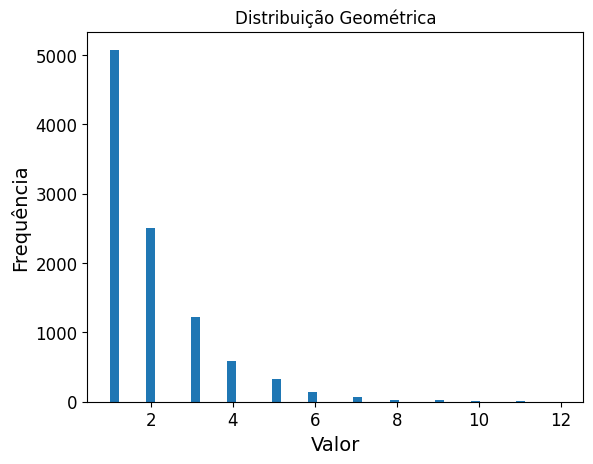

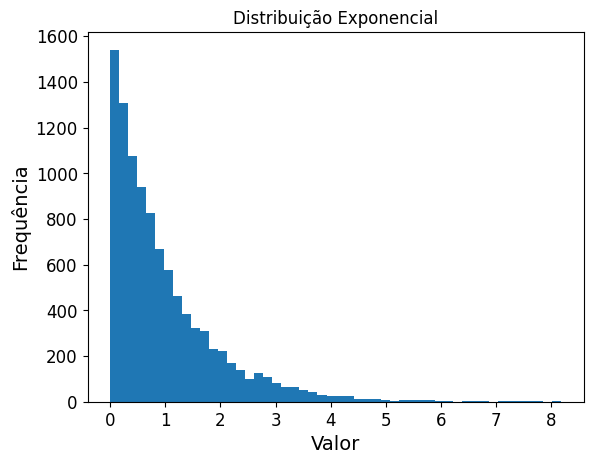

In [150]:
from scipy.stats import geom, expon

# Amostra de distribuição geométrica: número de tentativas até o primeiro sucesso (p=0.5)
geom_distrib=geom(0.5).rvs(10000, random_state=42)
# Amostra de distribuição exponencial: tempo entre eventos (taxa=1)
expon_distrib=expon(scale=1).rvs(10000, random_state=42)

# Visualiza a distribuição geométrica
plt.hist(geom_distrib, bins=50)
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.title("Distribuição Geométrica")
plt.show()

# Visualiza a distribuição exponencial
plt.hist(expon_distrib, bins=50)
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.title("Distribuição Exponencial")
plt.show()

# Exercise solutions

## 1.

Question: Try a Support Vector Machine regressor (`sklearn.svm.SVR`), with various hyperparameters such as `kernel="linear"` (with various values for the `C` hyperparameter) or `kernel="rbf"` (with various values for the `C` and `gamma` hyperparameters). Don't worry about what these hyperparameters mean for now. How does the best `SVR` predictor perform?

**Warning**: the following cell may take close to 30 minutes to run, or more depending on your hardware.

In [117]:
from sklearn.model_selection import GridSearchCV

param_grid = [
        {'kernel': ['linear'], 'C': [10., 30., 100., 300., 1000., 3000., 10000., 30000.0]},
        {'kernel': ['rbf'], 'C': [1.0, 3.0, 10., 30., 100., 300., 1000.0],
         'gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

svm_reg = SVR()
grid_search = GridSearchCV(svm_reg, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2)
grid_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] C=10.0, kernel=linear ...........................................


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] ............................ C=10.0, kernel=linear, total=   3.9s
[CV] C=10.0, kernel=linear ...........................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.9s remaining:    0.0s


[CV] ............................ C=10.0, kernel=linear, total=   3.9s
[CV] C=10.0, kernel=linear ...........................................
[CV] ............................ C=10.0, kernel=linear, total=   4.6s
[CV] C=10.0, kernel=linear ...........................................
[CV] ............................ C=10.0, kernel=linear, total=   4.2s
[CV] C=10.0, kernel=linear ...........................................
[CV] ............................ C=10.0, kernel=linear, total=   4.5s
[CV] C=30.0, kernel=linear ...........................................
[CV] ............................ C=30.0, kernel=linear, total=   4.1s
[CV] C=30.0, kernel=linear ...........................................
[CV] ............................ C=30.0, kernel=linear, total=   4.2s
[CV] C=30.0, kernel=linear ...........................................
[CV] ............................ C=30.0, kernel=linear, total=   4.3s
[CV] C=30.0, kernel=linear ...........................................
[CV] .

[Parallel(n_jobs=1)]: Done 250 out of 250 | elapsed: 26.4min finished


GridSearchCV(cv=5, estimator=SVR(),
             param_grid=[{'C': [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0,
                                10000.0, 30000.0],
                          'kernel': ['linear']},
                         {'C': [1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0],
                          'gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
                          'kernel': ['rbf']}],
             scoring='neg_mean_squared_error', verbose=2)

The best model achieves the following score (evaluated using 5-fold cross validation):

In [118]:
negative_mse = grid_search.best_score_
rmse = np.sqrt(-negative_mse)
rmse

70363.84006944533

That's much worse than the `RandomForestRegressor`. Let's check the best hyperparameters found:

In [119]:
grid_search.best_params_

{'C': 30000.0, 'kernel': 'linear'}

The linear kernel seems better than the RBF kernel. Notice that the value of `C` is the maximum tested value. When this happens you definitely want to launch the grid search again with higher values for `C` (removing the smallest values), because it is likely that higher values of `C` will be better.

## 2.

Question: Try replacing `GridSearchCV` with `RandomizedSearchCV`.

**Warning**: the following cell may take close to 45 minutes to run, or more depending on your hardware.

In [120]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, reciprocal

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `reciprocal()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'kernel': ['linear', 'rbf'],
        'C': reciprocal(20, 200000),
        'gamma': expon(scale=1.0),
    }

svm_reg = SVR()
rnd_search = RandomizedSearchCV(svm_reg, param_distributions=param_distribs,
                                n_iter=50, cv=5, scoring='neg_mean_squared_error',
                                verbose=2, random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] C=629.782329591372, gamma=3.010121430917521, kernel=linear ......


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV]  C=629.782329591372, gamma=3.010121430917521, kernel=linear, total=   4.2s
[CV] C=629.782329591372, gamma=3.010121430917521, kernel=linear ......


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.2s remaining:    0.0s


[CV]  C=629.782329591372, gamma=3.010121430917521, kernel=linear, total=   4.0s
[CV] C=629.782329591372, gamma=3.010121430917521, kernel=linear ......
[CV]  C=629.782329591372, gamma=3.010121430917521, kernel=linear, total=   4.5s
[CV] C=629.782329591372, gamma=3.010121430917521, kernel=linear ......
[CV]  C=629.782329591372, gamma=3.010121430917521, kernel=linear, total=   4.5s
[CV] C=629.782329591372, gamma=3.010121430917521, kernel=linear ......
[CV]  C=629.782329591372, gamma=3.010121430917521, kernel=linear, total=   4.3s
[CV] C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf ......
[CV]  C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf, total=   8.6s
[CV] C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf ......
[CV]  C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf, total=   9.1s
[CV] C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf ......
[CV]  C=26290.206464300216, gamma=0.9084469696321253, kernel=rbf, total=   8.8s
[CV] C=26290.2

[Parallel(n_jobs=1)]: Done 250 out of 250 | elapsed: 44.0min finished


RandomizedSearchCV(cv=5, estimator=SVR(), n_iter=50,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f9bd002c790>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f9bd002cb10>,
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

The best model achieves the following score (evaluated using 5-fold cross validation):

In [121]:
negative_mse = rnd_search.best_score_
rmse = np.sqrt(-negative_mse)
rmse

54767.960710084146

Now this is much closer to the performance of the `RandomForestRegressor` (but not quite there yet). Let's check the best hyperparameters found:

In [122]:
rnd_search.best_params_

{'C': 157055.10989448498, 'gamma': 0.26497040005002437, 'kernel': 'rbf'}

This time the search found a good set of hyperparameters for the RBF kernel. Randomized search tends to find better hyperparameters than grid search in the same amount of time.

Let's look at the exponential distribution we used, with `scale=1.0`. Note that some samples are much larger or smaller than 1.0, but when you look at the log of the distribution, you can see that most values are actually concentrated roughly in the range of exp(-2) to exp(+2), which is about 0.1 to 7.4.

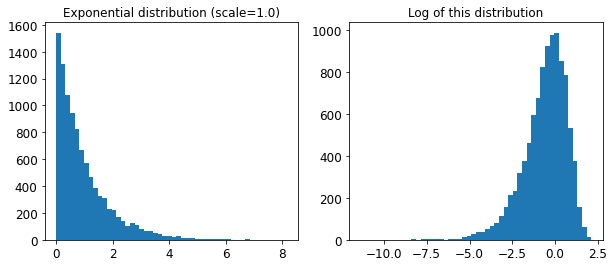

In [123]:
expon_distrib = expon(scale=1.)
samples = expon_distrib.rvs(10000, random_state=42)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title("Exponential distribution (scale=1.0)")
plt.hist(samples, bins=50)
plt.subplot(122)
plt.title("Log of this distribution")
plt.hist(np.log(samples), bins=50)
plt.show()

The distribution we used for `C` looks quite different: the scale of the samples is picked from a uniform distribution within a given range, which is why the right graph, which represents the log of the samples, looks roughly constant. This distribution is useful when you don't have a clue of what the target scale is:

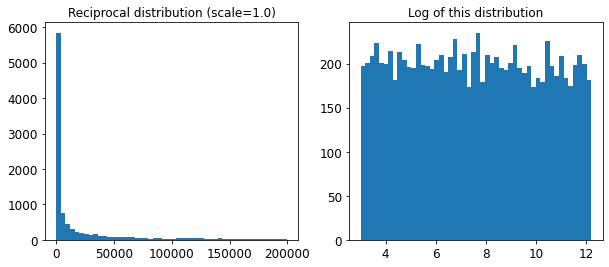

In [124]:
reciprocal_distrib = reciprocal(20, 200000)
samples = reciprocal_distrib.rvs(10000, random_state=42)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title("Reciprocal distribution (scale=1.0)")
plt.hist(samples, bins=50)
plt.subplot(122)
plt.title("Log of this distribution")
plt.hist(np.log(samples), bins=50)
plt.show()

The reciprocal distribution is useful when you have no idea what the scale of the hyperparameter should be (indeed, as you can see on the figure on the right, all scales are equally likely, within the given range), whereas the exponential distribution is best when you know (more or less) what the scale of the hyperparameter should be.

## 3.

Question: Try adding a transformer in the preparation pipeline to select only the most important attributes.

In [125]:
from sklearn.base import BaseEstimator, TransformerMixin

def indices_of_top_k(arr, k):
    return np.sort(np.argpartition(np.array(arr), -k)[-k:])

class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k
    def fit(self, X, y=None):
        self.feature_indices_ = indices_of_top_k(self.feature_importances, self.k)
        return self
    def transform(self, X):
        return X[:, self.feature_indices_]

Note: this feature selector assumes that you have already computed the feature importances somehow (for example using a `RandomForestRegressor`). You may be tempted to compute them directly in the `TopFeatureSelector`'s `fit()` method, however this would likely slow down grid/randomized search since the feature importances would have to be computed for every hyperparameter combination (unless you implement some sort of cache).

Let's define the number of top features we want to keep:

In [126]:
k = 5

Now let's look for the indices of the top k features:

In [127]:
top_k_feature_indices = indices_of_top_k(feature_importances, k)
top_k_feature_indices

array([ 0,  1,  7,  9, 12])

In [128]:
np.array(attributes)[top_k_feature_indices]

array(['longitude', 'latitude', 'median_income', 'pop_per_hhold',
       'INLAND'], dtype='<U18')

Let's double check that these are indeed the top k features:

In [129]:
sorted(zip(feature_importances, attributes), reverse=True)[:k]

[(0.36615898061813423, 'median_income'),
 (0.16478099356159054, 'INLAND'),
 (0.10879295677551575, 'pop_per_hhold'),
 (0.07334423551601243, 'longitude'),
 (0.06290907048262032, 'latitude')]

Looking good... Now let's create a new pipeline that runs the previously defined preparation pipeline, and adds top k feature selection:

In [130]:
preparation_and_feature_selection_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k))
])

In [131]:
housing_prepared_top_k_features = preparation_and_feature_selection_pipeline.fit_transform(housing)

Let's look at the features of the first 3 instances:

In [132]:
housing_prepared_top_k_features[0:3]

array([[-1.15604281,  0.77194962, -0.61493744, -0.08649871,  0.        ],
       [-1.17602483,  0.6596948 ,  1.33645936, -0.03353391,  0.        ],
       [ 1.18684903, -1.34218285, -0.5320456 , -0.09240499,  0.        ]])

Now let's double check that these are indeed the top k features:

In [133]:
housing_prepared[0:3, top_k_feature_indices]

array([[-1.15604281,  0.77194962, -0.61493744, -0.08649871,  0.        ],
       [-1.17602483,  0.6596948 ,  1.33645936, -0.03353391,  0.        ],
       [ 1.18684903, -1.34218285, -0.5320456 , -0.09240499,  0.        ]])

Works great!  :)

## 4.

Question: Try creating a single pipeline that does the full data preparation plus the final prediction.

In [134]:
prepare_select_and_predict_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k)),
    ('svm_reg', SVR(**rnd_search.best_params_))
])

In [135]:
prepare_select_and_predict_pipeline.fit(housing, housing_labels)

Pipeline(steps=[('preparation',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('attribs_adder',
                                                                   CombinedAttributesAdder()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                    

Let's try the full pipeline on a few instances:

In [136]:
some_data = housing.iloc[:4]
some_labels = housing_labels.iloc[:4]

print("Predictions:\t", prepare_select_and_predict_pipeline.predict(some_data))
print("Labels:\t\t", list(some_labels))

Predictions:	 [203214.28978849 371846.88152572 173295.65441612  47328.3970888 ]
Labels:		 [286600.0, 340600.0, 196900.0, 46300.0]


Well, the full pipeline seems to work fine. Of course, the predictions are not fantastic: they would be better if we used the best `RandomForestRegressor` that we found earlier, rather than the best `SVR`.

## 5.

Question: Automatically explore some preparation options using `GridSearchCV`.

**Warning**: the following cell may take close to 45 minutes to run, or more depending on your hardware.

**Note:** In the code below, I've set the `OneHotEncoder`'s `handle_unknown` hyperparameter to `'ignore'`, to avoid warnings during training. Without this, the `OneHotEncoder` would default to `handle_unknown='error'`, meaning that it would raise an error when transforming any data containing a category it didn't see during training. If we kept the default, then the `GridSearchCV` would run into errors during training when evaluating the folds in which not all the categories are in the training set. This is likely to happen since there's only one sample in the `'ISLAND'` category, and it may end up in the test set in some of the folds. So some folds would just be dropped by the `GridSearchCV`, and it's best to avoid that.

In [137]:
full_pipeline.named_transformers_["cat"].handle_unknown = 'ignore'

param_grid = [{
    'preparation__num__imputer__strategy': ['mean', 'median', 'most_frequent'],
    'feature_selection__k': list(range(1, len(feature_importances) + 1))
}]

grid_search_prep = GridSearchCV(prepare_select_and_predict_pipeline, param_grid, cv=5,
                                scoring='neg_mean_squared_error', verbose=2)
grid_search_prep.fit(housing, housing_labels)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] feature_selection__k=1, preparation__num__imputer__strategy=mean 


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV]  feature_selection__k=1, preparation__num__imputer__strategy=mean, total=   4.2s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=mean 


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.2s remaining:    0.0s


[CV]  feature_selection__k=1, preparation__num__imputer__strategy=mean, total=   5.2s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=mean 
[CV]  feature_selection__k=1, preparation__num__imputer__strategy=mean, total=   4.7s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=mean 
[CV]  feature_selection__k=1, preparation__num__imputer__strategy=mean, total=   4.7s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=mean 
[CV]  feature_selection__k=1, preparation__num__imputer__strategy=mean, total=   4.8s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=median 
[CV]  feature_selection__k=1, preparation__num__imputer__strategy=median, total=   5.1s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=median 
[CV]  feature_selection__k=1, preparation__num__imputer__strategy=median, total=   4.9s
[CV] feature_selection__k=1, preparation__num__imputer__strategy=median 
[CV]  feature_selection__k=1, preparation__num__

[Parallel(n_jobs=1)]: Done 240 out of 240 | elapsed: 42.3min finished


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preparation',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('attribs_adder',
                                                                                          CombinedAttributesAdder()),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
       

In [138]:
grid_search_prep.best_params_

{'feature_selection__k': 15,
 'preparation__num__imputer__strategy': 'most_frequent'}

The best imputer strategy is `most_frequent` and apparently almost all features are useful (15 out of 16). The last one (`ISLAND`) seems to just add some noise.

Congratulations! You already know quite a lot about Machine Learning. :)